## Conexión con GitHub

In [ ]:
import shutil
shutil.rmtree('C:/Users/anton/Downloads/.git', ignore_errors=True)
print("Repositorio eliminado de Descargas.")

In [ ]:
!git init
!git add .
!git commit -m "Commit inicial"
!git branch -M main
!git remote add origin https://github.com/antonmrtnz/lab2026.git
!git push -u origin main

Initialized empty Git repository in C:/Users/anton/Downloads/.git/


hint: Using 'master' as the name for the initial branch. This default branch name
hint: will change to "main" in Git 3.0. To configure the initial branch name
hint: to use in all of your new repositories, which will suppress this warning,
hint: call:
hint:
hint: 	git config --global init.defaultBranch <name>
hint:
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint:
hint: 	git branch -m <name>
hint:
hint: Disable this message with "git config set advice.defaultBranchName false"


In [1]:
# =============================================================
# Imports — Lab Astronomía 2026 · S2
# =============================================================
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits
from astropy import units as u
from astropy.visualization import ZScaleInterval, ImageNormalize, SqrtStretch
from astropy.stats import sigma_clipped_stats

from ccdproc import CCDData, Combiner, subtract_bias, subtract_dark

# Directorios del curso
CALIB_DIR = Path("calib_data")
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

print("✅ Imports OK")
import astropy, ccdproc
print(f"   astropy  {astropy.__version__}")
print(f"   ccdproc  {ccdproc.__version__}")

✅ Imports OK
   astropy  8.0.1
   ccdproc  2.5.1


## BIAS

In [2]:
#Vamos a ver el procedimiento completo para llegar a la imagen calibrada, verificamos los BIAS
import glob 
from astropy.io import fits

path_bias = "lab2026/data/ccd/bias/*.fits" #Change to your local path 
archivo_bias = sorted(glob.glob("lab2026/data/ccd/bias/*.fits"))

datos_bias = []
headers_bias = []

#Iterando
for archivo in archivo_bias:
    with fits.open(archivo) as hdul:
        hdul.info()                        # estructura del archivo
        header = hdul[0].header.copy()     # copia del header
        data   = hdul[0].data.copy()       # copia de los datos como numpy array
        print(f"Leído: {archivo}")
        
print()
print(f"Archivos de bias encontrados (datos): {len(datos_bias)}")
for f in archivo_bias:
    print(f"  {f}")

Filename: lab2026/data/ccd/bias\ccd.001.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2080, 4128)   int16 (rescales to uint16)   
Leído: lab2026/data/ccd/bias\ccd.001.0.fits
Filename: lab2026/data/ccd/bias\ccd.002.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2080, 4128)   int16 (rescales to uint16)   
Leído: lab2026/data/ccd/bias\ccd.002.0.fits
Filename: lab2026/data/ccd/bias\ccd.003.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2080, 4128)   int16 (rescales to uint16)   
Leído: lab2026/data/ccd/bias\ccd.003.0.fits
Filename: lab2026/data/ccd/bias\ccd.004.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2080, 4128)   int16 (rescales to uint16)   
Leído: lab2026/data/ccd/bias\ccd.004.0.fits
Filename: lab2026/data/ccd/bias\ccd.005.

## Opening a BIAS file 

=== Header del bias ===
  IMAGETYP     BIAS
  EXPTIME      0.0
  GAIN         1.1
  RDNOISE      — no disponible —
  NAXIS1       2080
  NAXIS2       4128

=== Array ===
  Forma   : (4128, 2080)
  Media   : 1144.55 ADU
  Mediana : 1137.00 ADU
  Std     : 43.30 ADU
  Mín/Máx : 353 / 65535 ADU


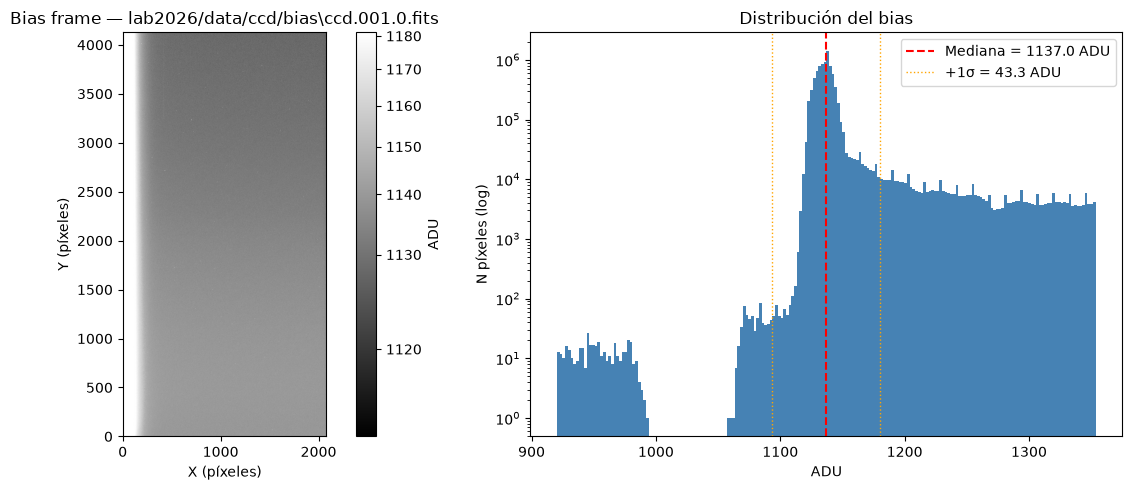

In [3]:
# Abrir un bias de ejemplo e inspeccionar
bias_ejemplo = CCDData.read(archivo_bias[0], unit="adu")

print("=== Header del bias ===")
for kw in ["IMAGETYP", "EXPTIME", "GAIN", "RDNOISE", "NAXIS1", "NAXIS2"]:
    print(f"  {kw:<12} {bias_ejemplo.header.get(kw, '— no disponible —')}")

print(f"\n=== Array ===")
print(f"  Forma   : {bias_ejemplo.data.shape}")
print(f"  Media   : {bias_ejemplo.data.mean():.2f} ADU")
print(f"  Mediana : {np.median(bias_ejemplo.data):.2f} ADU")
print(f"  Std     : {bias_ejemplo.data.std():.2f} ADU")
print(f"  Mín/Máx : {bias_ejemplo.data.min():.0f} / {bias_ejemplo.data.max():.0f} ADU")


# Visualización del bias: imagen + histograma
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Imagen ---
norm = ImageNormalize(bias_ejemplo.data, interval=ZScaleInterval(), stretch=SqrtStretch())
im = axes[0].imshow(bias_ejemplo.data, norm=norm, cmap="gray", origin="lower")
plt.colorbar(im, ax=axes[0], label="ADU")
axes[0].set_title(f"Bias frame — {archivo_bias[0]}")
axes[0].set_xlabel("X (píxeles)")
axes[0].set_ylabel("Y (píxeles)")

# --- Histograma ---
med = np.median(bias_ejemplo.data)
std = bias_ejemplo.data.std()
axes[1].hist(bias_ejemplo.data.flatten(), bins=200,
             range=(med - 5*std, med + 5*std),
             color="steelblue", edgecolor="none", log=True)
axes[1].axvline(med, color="red",    lw=1.5, ls="--", label=f"Mediana = {med:.1f} ADU")
axes[1].axvline(med + std, color="orange", lw=1, ls=":", label=f"+1σ = {std:.1f} ADU")
axes[1].axvline(med - std, color="orange", lw=1, ls=":")
axes[1].set_xlabel("ADU")
axes[1].set_ylabel("N píxeles (log)")
axes[1].set_title("Distribución del bias")
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_bias_ejemplo.png", dpi=150, bbox_inches="tight")
plt.show()


## Master BIAS creation

In [5]:
# Cargar todos los bias frames en una lista de CCDData
bias_list = []
for f in archivo_bias:
    ccd = CCDData.read(f, unit="adu")
    bias_list.append(ccd)
    print(f"  Cargado: {f.split('/')[-1]}  |  mediana = {np.median(ccd.data):.1f} ADU")

print(f"\nTotal de bias frames cargados: {len(bias_list)}")

  Cargado: bias\ccd.001.0.fits  |  mediana = 1137.0 ADU
  Cargado: bias\ccd.002.0.fits  |  mediana = 1126.0 ADU
  Cargado: bias\ccd.003.0.fits  |  mediana = 1123.0 ADU
  Cargado: bias\ccd.004.0.fits  |  mediana = 1122.0 ADU


  Cargado: bias\ccd.005.0.fits  |  mediana = 1121.0 ADU
  Cargado: bias\ccd.006.0.fits  |  mediana = 1121.0 ADU
  Cargado: bias\master_bias.fits  |  mediana = 1123.5 ADU

Total de bias frames cargados: 7


## Combinación Sigma Clipping y Visualización Master BIAS

Master Bias construido:
  Frames combinados : 7
  Mediana           : 1123.50 ADU
  Std               : 42.05 ADU
  Guardado en       : lab2026/data/ccd/bias/master_bias_ccd.fits


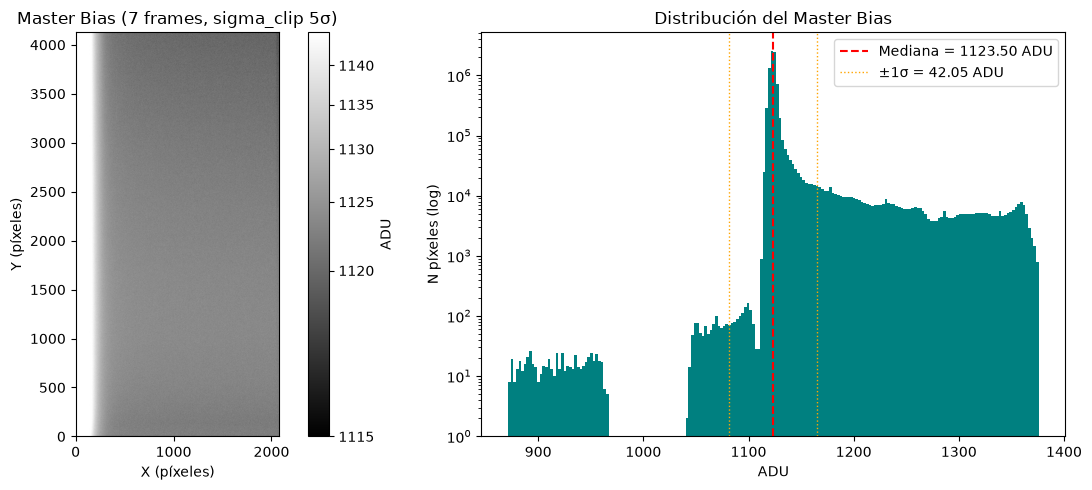

In [7]:
# Crear el combinador y aplicar sigma clipping
combiner_bias = Combiner(bias_list)

# Sigma clipping: rechaza píxeles a más de 5σ de la mediana (conservador)
combiner_bias.sigma_clipping(low_thresh=5, high_thresh=5)

# Combinación por mediana
master_bias = combiner_bias.median_combine()
master_bias.header["IMAGETYP"] = "MASTER_BIAS"
master_bias.header["NCOMBINE"] = len(bias_list)
master_bias.header["PIPELINE"] = "Lab2026v1"

# Guardar
ruta_guardado = f"lab2026/data/ccd/bias/master_bias_ccd.fits"
master_bias.write(ruta_guardado, overwrite=True)

print("Master Bias construido:")
print(f"  Frames combinados : {len(bias_list)}")
print(f"  Mediana           : {np.median(master_bias.data):.2f} ADU")
print(f"  Std               : {master_bias.data.std():.2f} ADU")
print(f"  Guardado en       : {ruta_guardado}")

# Visualización del Master Bias
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Imagen
norm = ImageNormalize(master_bias.data, interval=ZScaleInterval(), stretch=SqrtStretch())
im = axes[0].imshow(master_bias.data, norm=norm, cmap="gray", origin="lower")
plt.colorbar(im, ax=axes[0], label="ADU")
axes[0].set_title(f"Master Bias ({len(bias_list)} frames, sigma_clip 5σ)")
axes[0].set_xlabel("X (píxeles)")
axes[0].set_ylabel("Y (píxeles)")

# Histograma
med = np.median(master_bias.data)
std = master_bias.data.std()
axes[1].hist(master_bias.data.flatten(), bins=200,
             range=(med - 6*std, med + 6*std),
             color="teal", edgecolor="none", log=True)
axes[1].axvline(med, color="red",    lw=1.5, ls="--", label=f"Mediana = {med:.2f} ADU")
axes[1].axvline(med + std, color="orange", lw=1, ls=":", label=f"±1σ = {std:.2f} ADU")
axes[1].axvline(med - std, color="orange", lw=1, ls=":")
axes[1].set_xlabel("ADU")
axes[1].set_ylabel("N píxeles (log)")
axes[1].set_title("Distribución del Master Bias")
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_master_bias.png", dpi=150, bbox_inches="tight")
plt.show()

## LECTURA ARCHIVOS DARK

In [9]:
# Cargar darks y restar bias a cada uno
# Listar archivos de dark
path_bias = "lab2026/data/ccd/dark/*.fits"
dark_files = sorted(glob.glob("lab2026/data/ccd/dark/*.fits"))
print(f"Archivos de dark encontrados: {len(dark_files)}")
for f in dark_files:
    print(f"  {f.split('/')[-1]}")

datos_dark = []
headers_dark = []

#Iterando
for archivo in dark_files:
    with fits.open(archivo) as hdul:
        hdul.info()                        # estructura del archivo
        header = hdul[0].header.copy()     # copia del header
        data   = hdul[0].data.copy()       # copia de los datos como numpy array

        headers_dark.append(header)
        datos_dark.append(data)
        
        tiempo_exp = header.get("EXPTIME", "No encontrado")
        nombre_archivo = archivo.split('/')[-1]
        
        print(f"Leído: {archivo}")
        print(f"Leído: {nombre_archivo:<12} | EXPTIME: {tiempo_exp} s")
print()
print(f"Archivos de dark encontrados (datos): {len(datos_dark)}")
for f in dark_files:
    print(f"  {f}")

dark_bias_sub = []
for f in dark_files:
    d = CCDData.read(f, unit="adu")
    d_sub = subtract_bias(d, master_bias)
    d.data[d.data < 0] = 0.0
    
    dark_bias_sub.append(d_sub)
    t = d.header.get("EXPTIME", "?")
    print(f"  {f}  |  EXPTIME={t}s  |  mediana (post-bias sub) = {np.median(d_sub):.2f} ADU")

print(f"\nTotal de dark frames (bias-subtracted): {len(dark_bias_sub)}")

Archivos de dark encontrados: 4
  dark\ccd.013.0.fits
  dark\ccd.014.0.fits
  dark\ccd.015.0.fits
  dark\master_dark.fits
Filename: lab2026/data/ccd/dark\ccd.013.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2080, 4128)   int16 (rescales to uint16)   
Leído: lab2026/data/ccd/dark\ccd.013.0.fits
Leído: dark\ccd.013.0.fits | EXPTIME: 300.0 s
Filename: lab2026/data/ccd/dark\ccd.014.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2080, 4128)   int16 (rescales to uint16)   
Leído: lab2026/data/ccd/dark\ccd.014.0.fits
Leído: dark\ccd.014.0.fits | EXPTIME: 300.0 s
Filename: lab2026/data/ccd/dark\ccd.015.0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      43   (2080, 4128)   int16 (rescales to uint16)   
Leído: lab2026/data/ccd/dark\ccd.015.0.fits
Leído: dark\ccd.015.0.fits | EXPTIME: 300.0 s
Filename: lab2026/da

## Cargar Darks y restar el MASTER BIAS

In [10]:
# Cargar darks y restar bias a cada uno
master_bias = CCDData.read("lab2026/data/ccd/bias/master_bias_ccd.fits", unit="adu")
dark_bias_sub = []
for f in dark_files:
    d = CCDData.read(f, unit="adu")
    d_sub = subtract_bias(d, master_bias)
    d.data[d.data < 0] = 0.0
    
    dark_bias_sub.append(d_sub)
    t = d.header.get("EXPTIME", "?")
    print(f"  {f}  |  EXPTIME={t}s  |  mediana (post-bias sub) = {np.median(d_sub):.2f} ADU")

print(f"\nTotal de dark frames (bias-subtracted): {len(dark_bias_sub)}")

  lab2026/data/ccd/dark\ccd.013.0.fits  |  EXPTIME=300.0s  |  mediana (post-bias sub) = 69.00 ADU
  lab2026/data/ccd/dark\ccd.014.0.fits  |  EXPTIME=300.0s  |  mediana (post-bias sub) = 69.00 ADU
  lab2026/data/ccd/dark\ccd.015.0.fits  |  EXPTIME=300.0s  |  mediana (post-bias sub) = 68.50 ADU
  lab2026/data/ccd/dark\master_dark.fits  |  EXPTIME=300.0s  |  mediana (post-bias sub) = -1055.00 ADU

Total de dark frames (bias-subtracted): 4


In [12]:
# Combinar darks con sigma clipping
combiner_dark = Combiner(dark_bias_sub)
combiner_dark.sigma_clipping(low_thresh=5, high_thresh=5)
master_dark = combiner_dark.median_combine()

# Metadata
t_dark_exp = dark_files[0]  # para recuperar EXPTIME del primer dark
with fits.open(t_dark_exp) as hdul:
    t_exp_dark = hdul[0].header.get("EXPTIME", 300.0)

master_dark.header["IMAGETYP"] = "MASTER_DARK"
master_dark.header["NCOMBINE"] = len(dark_bias_sub)
master_dark.header["EXPTIME"]  = t_exp_dark
master_dark.header["BIASSUB"]  = (True, "Bias restado antes de combinar")
master_dark.header["PIPELINE"] = "Lab2026v1"

# Guardar
ruta_guardado = f"lab2026/data/ccd/dark/master_dark_ccd.fits"
master_dark.write(ruta_guardado, overwrite=True)

print("Master Dark construido:")
print(f"  Frames combinados : {len(dark_bias_sub)}")
print(f"  EXPTIME           : {t_exp_dark:.0f} s")
print(f"  Mediana           : {np.median(master_dark.data):.4f} ADU")
print(f"  Std               : {master_dark.data.std():.4f} ADU")
print(f"  Guardado en       : {ruta_guardado}")

Master Dark construido:
  Frames combinados : 4
  EXPTIME           : 300 s
  Mediana           : 67.0000 ADU
  Std               : 134.7079 ADU
  Guardado en       : lab2026/data/ccd/dark/master_dark_ccd.fits


## Sigma Clipping

In [ ]:
# Demostración sintética: impacto de un outlier en promedio vs mediana
rng = np.random.default_rng(42)

# Simular 15 bias frames con valor ~1500 ADU
n_frames = 15
shape = (100, 100)
frames = [rng.normal(1500, 8, shape) for _ in range(n_frames)]

# Inyectar un rayo cósmico en el frame 7
frames[7][40:42, 50:52] = 60000  # saturado

stack = np.array(frames)

# Combinaciones
mean_comb   = stack.mean(axis=0)
median_comb = np.median(stack, axis=0)
_, median_sc, _ = sigma_clipped_stats(stack, sigma=5, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
norm_ref = ImageNormalize(median_comb, interval=ZScaleInterval(), stretch=SqrtStretch())

for ax, img, titulo in zip(axes,
    [mean_comb, median_comb, median_sc],
    ["Media simple (contaminada)", "Mediana simple", "Sigma Clipping + Mediana ✅"]):
    im = ax.imshow(img, norm=norm_ref, cmap="gray", origin="lower")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(f"Media pix centro: {img[45:55,45:55].mean():.1f} ADU")
    plt.colorbar(im, ax=ax)

plt.suptitle("Impacto del rayo cósmico en distintos métodos de combinación", y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_sigma_clipping_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Zona del rayo cósmico — Media: {mean_comb[40,50]:.0f} ADU  |  Mediana SC: {median_sc[40,50]:.1f} ADU")

## COMPARACIÓN MASTER BIAS VS MASTER DARK

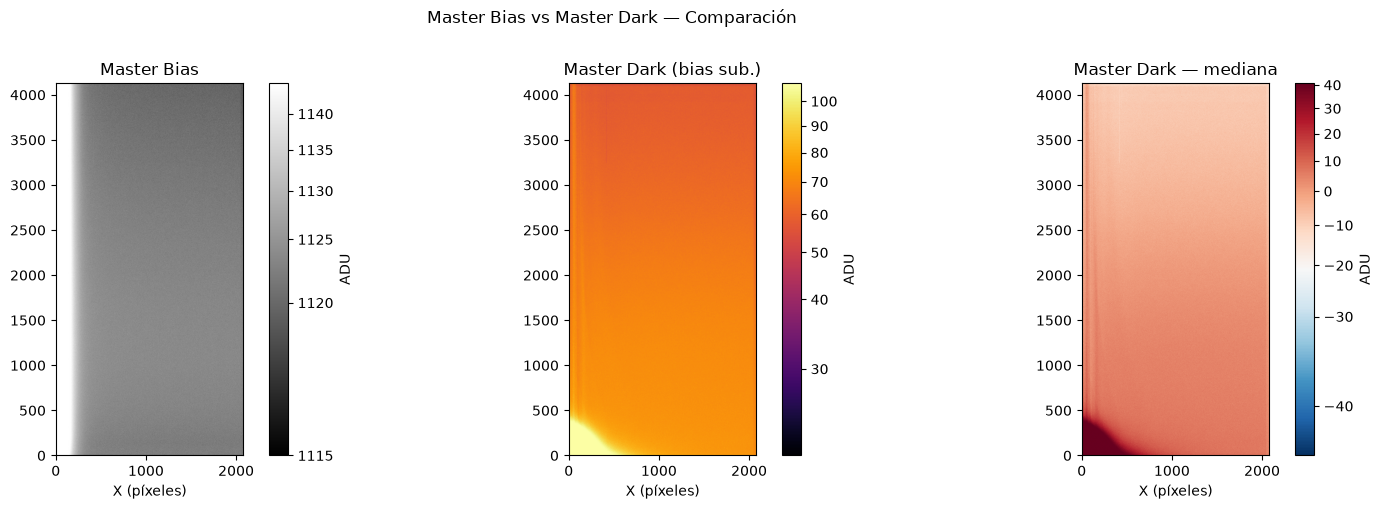

In [13]:
# Comparación visual Master Bias vs Master Dark
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

imgs   = [master_bias.data, master_dark.data,
          master_dark.data - np.median(master_dark.data)]
titulos = ["Master Bias", "Master Dark (bias sub.)", "Master Dark — mediana"]
cmaps  = ["gray", "inferno", "RdBu_r"]

for ax, img, titulo, cmap in zip(axes, imgs, titulos, cmaps):
    norm = ImageNormalize(img, interval=ZScaleInterval(), stretch=SqrtStretch())
    im = ax.imshow(img, norm=norm, cmap=cmap, origin="lower")
    plt.colorbar(im, ax=ax, label="ADU")
    ax.set_title(titulo)
    ax.set_xlabel("X (píxeles)")

plt.suptitle("Master Bias vs Master Dark — Comparación", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "S2_bias_vs_dark.png", dpi=150, bbox_inches="tight")
plt.show()

## Flats

In [15]:
import glob
import numpy as np
from astropy.nddata import CCDData
from astropy.io import fits

# 1. Buscar todos los archivos flat
ruta_flats = "lab2026/data/ccd/flat/*.fits"
archivos_flat = sorted(glob.glob(ruta_flats))
print(f"Archivos Flat encontrados: {len(archivos_flat)}\n")

flats_calibrados = []

# 2. Procesamiento y normalización imagen por imagen
for f in archivos_flat:
    # Leemos la imagen
    flat = CCDData.read(f, unit="adu")
    
    # Restamos el Master Bias y truncamos los negativos por seguridad física
    flat_sin_bias = flat.data - master_bias.data
    flat_sin_bias[flat_sin_bias < 0] = 0.0
    
    # NORMALIZACIÓN: Dividimos la imagen por su propia mediana
    mediana_flat = np.median(flat_sin_bias)
    flat_normalizado = flat_sin_bias / mediana_flat
    
    flats_calibrados.append(flat_normalizado)
    
    # Limpiamos el nombre
    nombre = f.replace('\\', '/').split('/')[-1]
    print(f"Procesado: {nombre:<15} | Mediana original: {mediana_flat:.2f} ADU")

# 3. Apilar y combinar todos los flats normalizados
cubo_flats = np.array(flats_calibrados)
master_flat_data = np.median(cubo_flats, axis=0)

# 4. Extracción y reparación del header base
with fits.open(archivos_flat[0]) as hdul:
    hdul.verify('silentfix')  # Repara las tarjetas "unparsable"
    header_flat = hdul[0].header.copy()

# 5. Limpieza extrema del header (Prevención de VerifyError)
if 'COMMENT' in header_flat: del header_flat['COMMENT']
if 'HISTORY' in header_flat: del header_flat['HISTORY']
if '' in header_flat: del header_flat['']

for key in list(header_flat.keys()):
    valor = header_flat[key]
    if isinstance(valor, str) and '\x00' in valor:
        del header_flat[key]
    elif '\x00' in str(valor):
        del header_flat[key]

# 6. Actualización de metadatos y guardado
header_flat['IMAGETYP'] = 'MASTER_FLAT'
header_flat['HISTORY'] = 'Master Flat (Unificado): Bias restado y normalizado'

ruta_guardado = "lab2026/data/ccd/flat/master_flat_ccd.fits" #cambiar siempre si se quiere un nuevo ejemplo

hdu_flat = fits.PrimaryHDU(master_flat_data, header=header_flat)
hdu_flat.writeto(ruta_guardado, overwrite=True, output_verify="silentfix")

print(f"\n✅ Master Flat construido y guardado en: {ruta_guardado}")

Archivos Flat encontrados: 4

Procesado: ccd.014.0.fits  | Mediana original: 20182.00 ADU
Procesado: ccd.015.0.fits  | Mediana original: 20178.50 ADU
Procesado: ccd.016.0.fits  | Mediana original: 20167.00 ADU


C:\Users\anton\AppData\Local\Temp\ipykernel_25252\3939980468.py:24: RuntimeWarning: invalid value encountered in divide
  flat_normalizado = flat_sin_bias / mediana_flat


Procesado: master_flat.fits | Mediana original: 0.00 ADU

✅ Master Flat construido y guardado en: lab2026/data/ccd/flat/master_flat_ccd.fits


## Construcción Light

In [16]:
import os
import glob
import numpy as np
from astropy.io import fits

# 1. Cargar los archivos maestros
# (Verifica que estas rutas apunten a donde guardaste tus masters finales)
master_bias = fits.getdata("lab2026/data/ccd/bias/master_bias_ccd.fits")
master_dark = fits.getdata("lab2026/data/ccd/dark/master_dark_ccd.fits")
master_flat = fits.getdata("lab2026/data/ccd/flat/master_flat_ccd.fits")

# 2. Preparar el directorio de Lights
ruta_lights = "lab2026/data/ccd/light/*.fits" # Ajusta a la carpeta de ciencias crudas
archivos_light = sorted(glob.glob(ruta_lights))

# Carpeta para guardar los resultados
carpeta_salida = "lab2026/data/ccd/light/"
os.makedirs(carpeta_salida, exist_ok=True)

print(f"Archivos Light a calibrar: {len(archivos_light)}\n")

# 3. Procesar cada imagen
for f in archivos_light:
    with fits.open(f) as hdul:
        hdul.verify('silentfix')
        header = hdul[0].header.copy()
        # Convertir a float32 para la división decimal
        data_light = hdul[0].data.astype(np.float32)

    # --- LA MATEMÁTICA DE CALIBRACIÓN ---
    
    # A) Restar el Bias
    data_calib = data_light - master_bias
    
    # B) Restar el Dark
    data_calib = data_calib - master_dark
    
    # Prevenir píxeles matemáticamente imposibles (ruido bajo cero)
    data_calib[data_calib < 0] = 0.0
    
    # C) Dividir por el Flat (protegiendo contra división por cero)
    flat_seguro = np.where(master_flat == 0, 1.0, master_flat)
    data_calib = data_calib / flat_seguro

    # --- LIMPIEZA EXTREMA DE CABECERAS ---
    if 'COMMENT' in header: del header['COMMENT']
    if 'HISTORY' in header: del header['HISTORY']
    if '' in header: del header['']

    for key in list(header.keys()):
        valor = header[key]
        if isinstance(valor, str) and '\x00' in valor:
            del header[key]
        elif '\x00' in str(valor):
            del header[key]

    # --- GUARDADO ---
    header['IMAGETYP'] = 'CALIBRATED_LIGHT'
    header['HISTORY'] = 'Calibrado: Bias restado, Dark restado, dividido por Master Flat'
    
    # Manejo de rutas Windows y agregado del sufijo _calib
    nombre_limpio = f.replace('\\', '/').split('/')[-1]
    nombre_archivo = nombre_limpio.replace('.fits', '_calib.fits')
    ruta_guardado = os.path.join(carpeta_salida, nombre_archivo)
    
    fits.PrimaryHDU(data_calib, header=header).writeto(ruta_guardado, overwrite=True, output_verify="silentfix")
    
    print(f"✅ Listo: {nombre_archivo} calibrado exitosamente.")

print("\n ¡Calibración de ciencia completada!")

Archivos Light a calibrar: 2

✅ Listo: ccd.037.0_calib.fits calibrado exitosamente.
✅ Listo: ccd.037.0_calib_calib.fits calibrado exitosamente.

 ¡Calibración de ciencia completada!
